<a href="https://colab.research.google.com/github/ArdiArtani/Stock-Market-Prediction/blob/main/Stock_Market_Prediction_using_Multivariate_Time_Series_and_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Libraries


In [ ]:
# Load libraries to use
import math # Mathematical Functions
import pandas as pd # Analysis and manipulating data
import numpy as np # Scientific computing
from datetime import date, timedelta, datetime # Date functions
from pandas.plotting import register_matplotlib_converters # Plotting functions for calendar dates
import matplotlib.pyplot as plt # Visualization
import matplotlib.dates as mdates # Formatting dates
from sklearn.metrics import mean_absolute_error, mean_squared_error # Measure model performance / errors
from keras.models import Sequential # Deep Learning Library, used for neural networks
from keras.layers import LSTM, Dense, Dropout # Deep Learning classes for recurrent and regular densely-connected layers
from keras.callbacks import EarlyStopping # Stop model training
from sklearn.preprocessing import RobustScaler, MinMaxScaler # This Scaler removes the median and scales the data according to the quantile range to normalize the price data
import seaborn as sns

In [ ]:
def clean(df):
  cdf = df
  cdf['Date'] =pd.to_datetime(cdf['Date'])
  cdf.set_index('Date', inplace = True)
  return cdf

In [ ]:
!pip install yfinance

     |████████████████████████████████| 6.3 MB 10.3 MB/s 
  Attempting uninstall: lxml
    Found existing installation: lxml 4.2.6
    Uninstalling lxml-4.2.6:
      Successfully uninstalled lxml-4.2.6


# Load the Time Series Data

In [ ]:
#Setting the timeframe for the data extraction
today = "2021-12-07" # date.today()
# date_today = today.strftime("%Y-%m-%d")
date_start = '2011-12-07'

stockname = 'APPLE'
symbol = 'AAPL'


import yfinance as yf
apple_df = yf.download(symbol, start = date_start, end=today)

[*********************100%***********************]  1 of 1 completed


In [ ]:
apple_df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-12-07,13.926071,13.962143,13.812857,13.896071,11.914007,304746400
2011-12-08,13.980357,14.125000,13.936786,13.952143,11.962080,376356400
2011-12-09,14.030357,14.072857,13.965357,14.057857,12.052715,296993200
2011-12-12,13.988571,14.067857,13.908929,13.994286,11.998211,301067200
2011-12-13,14.035714,14.121429,13.825000,13.886071,11.905433,338928800
...,...,...,...,...,...,...
2021-11-30,159.990005,165.520004,159.919998,165.300003,165.300003,174048100
2021-12-01,167.479996,170.300003,164.529999,164.770004,164.770004,152052500
2021-12-02,158.740005,164.199997,157.800003,163.759995,163.759995,136739200


# Exploratoy Data Analysis

## Apple

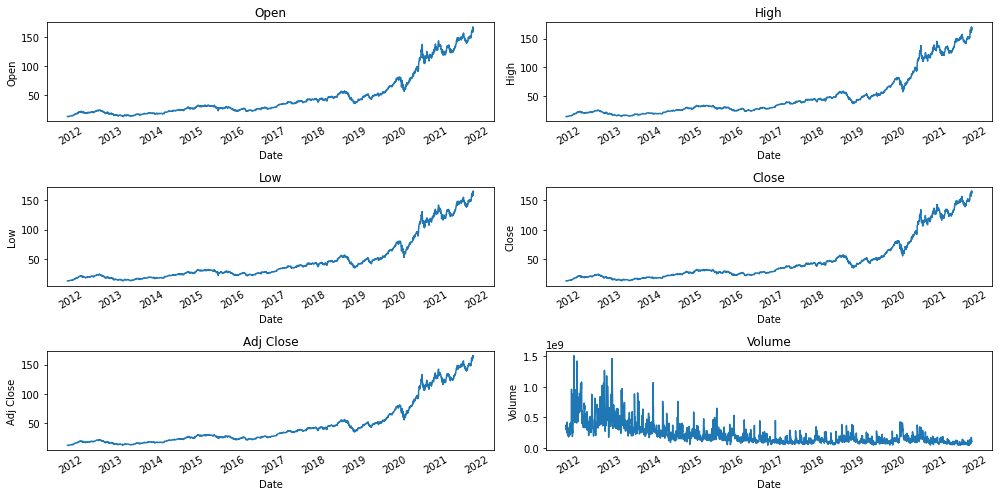

In [ ]:
#Plot line charts

apple_df_plot = apple_df.copy()

list_length = apple_df_plot.shape[1]
ncols = 2
nrows = int(round(list_length / ncols, 0))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
fig.subplots_adjust(hspace=0.5, wspace=0.5)
for i in range(0, list_length):
        ax = plt.subplot(nrows,ncols,i+1)
        sns.lineplot(data = apple_df_plot.iloc[:, i], ax=ax)
        ax.set_title(apple_df_plot.columns[i])
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.tight_layout()
plt.show()

# Scaling and Feature Selection

In [ ]:
# Indexing Batches
apple_train_df = apple_df.sort_values(by=['Date']).copy()


# Safe a copy of the dates index, before we need to reset it to numbers
apple_date_index = apple_train_df.index


#Reset the index, so we can conver the date-index to a number-index
apple_train_df = apple_train_df.reset_index(drop=True).copy()


apple_train_df.head(5)

,Open,High,Low,Close,Adj Close,Volume
0,13.926071,13.962143,13.812857,13.896071,11.914007,304746400
1,13.980357,14.125000,13.936786,13.952143,11.962080,376356400
2,14.030357,14.072857,13.965357,14.057857,12.052715,296993200
3,13.988571,14.067857,13.908929,13.994286,11.998211,301067200
4,14.035714,14.121429,13.825000,13.886071,11.905433,338928800


In [ ]:
# List of considered Features
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']

# Create the dataset with features and filter the data to te list of FEATURES
apple_data = pd.DataFrame(apple_train_df)
apple_data_filtered = apple_data[FEATURES]


# Add a prediction column (target) and set dummy values to prepare the data for scaling
apple_data_filtered_ext = apple_data_filtered.copy()
apple_data_filtered_ext['Prediction'] = apple_data_filtered_ext['Close']

apple_data_filtered_ext.tail()

,Open,High,Low,Close,Volume,Prediction
2511,159.990005,165.520004,159.919998,165.300003,174048100,165.300003
2512,167.479996,170.300003,164.529999,164.770004,152052500,164.770004
2513,158.740005,164.199997,157.800003,163.759995,136739200,163.759995
2514,164.020004,164.960007,159.720001,161.839996,117938300,161.839996
2515,164.289993,167.880005,164.279999,165.320007,107497000,165.320007


In [ ]:
# Get the number of rows in the data
nrows = apple_data_filtered.shape[0] # It is the same for all datasets

# Convert the data to numpy values
apple_np_data_unscaled = np.array(apple_data_filtered)
apple_np_data = np.reshape(apple_np_data_unscaled, (nrows, -1))


print(apple_np_data.shape)


# Transform the data by scaling each feature to a range between 0 and 1
scaler = MinMaxScaler()
apple_np_data_scaled = scaler.fit_transform(apple_np_data_unscaled)


# Create a separate scaler that works on a single column for scaling predictions
scaler_pred = MinMaxScaler()
apple_df_Close = pd.DataFrame(apple_data_filtered_ext['Close'])
apple_np_Close_scaled = scaler_pred.fit_transform(apple_df_Close)



(2516, 5)


# Transforming the Data

In [ ]:
# Set the sequence length - this is the timeframe used to make a single prediction
sequence_length = 50

#Prediction Index
apple_index_Close = apple_data.columns.get_loc("Close")

# Split the training data into train and test data sets
# As a first step, we get the number of rows to train the model on 80% of the data
train_data_len = math.ceil(apple_np_data_scaled.shape[0] * 0.8)

# Create the training and test data
apple_train_data = apple_np_data_scaled[0:train_data_len, :]
apple_test_data = apple_np_data_scaled[train_data_len - sequence_length:, :]


# The RNN needs data with the format of [samples, time steps, features]
# Here, we create N samples, sequence_length time steps per sample, and 5 features
def partition_dataset(sequence_length, data):
    x, y = [], []
    data_len = data.shape[0]
    for i in range(sequence_length, data_len):
        x.append(data[i-sequence_length:i,:]) #contains sequence_length values 0-sequence_length * columns
        y.append(data[i, apple_index_Close]) #contains the prediction values for validation,  for single-step prediction

    # Convert the x and y to numpy arrays
    x = np.array(x)
    y = np.array(y)
    return x, y

# Generate training data and test data
apple_x_train, apple_y_train = partition_dataset(sequence_length, apple_train_data)
apple_x_test, apple_y_test = partition_dataset(sequence_length, apple_test_data)



# Print the shapes: the result is: (rows, training_sequence, features) (prediction value, )
print('Apple Train:', apple_x_train.shape, apple_y_train.shape)
print('Apple Test: ', apple_x_test.shape, apple_y_test.shape)


# Validate that the prediction value and the input match up
# The last close price of the second input sample should equal the first prediction value
print('Apple x: ', apple_x_train[1][sequence_length-1][apple_index_Close])
print('Apple y: ', apple_y_train[0])


Apple Train: (1963, 50, 5) (1963,)
Apple Test:  (503, 50, 5) (503,)
Apple x:  0.03197867770651919
Apple y:  0.03197867770651919


# Training the Multivariate Prediction Model

In [ ]:
# Configure the neural network model
model = Sequential()

# Model with n_neurons inputshape Timestamps, each with x_train.shape[2] variables
n_neurons = apple_x_train.shape[1] * apple_x_train.shape[2]
print(n_neurons, apple_x_train.shape[1], apple_x_train.shape[2])
model.add(LSTM(n_neurons, return_sequences=True, input_shape=(apple_x_train.shape[1], apple_x_train.shape[2])))
model.add(LSTM(n_neurons, return_sequences=False))
model.add(Dense(5))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

250 50 5


In [ ]:
# Training the model
epochs = 50
batch_size = 16
early_stop = EarlyStopping(monitor='loss', patience=5, verbose=1)
history = model.fit(apple_x_train, apple_y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(apple_x_test, apple_y_test)
                   )

                    #callbacks=[early_stop])

Epoch 1/50
123/123 [==============================] - 41s 303ms/step - loss: 3.8011e-04 - val_loss: 8.6528e-04
Epoch 2/50
123/123 [==============================] - 35s 284ms/step - loss: 5.1111e-05 - val_loss: 0.0013
Epoch 3/50
123/123 [==============================] - 35s 288ms/step - loss: 5.5430e-05 - val_loss: 9.1470e-04
Epoch 4/50
123/123 [==============================] - 34s 278ms/step - loss: 3.8077e-05 - val_loss: 0.0012
Epoch 5/50
123/123 [==============================] - 35s 281ms/step - loss: 4.2034e-05 - val_loss: 5.2368e-04
Epoch 6/50
123/123 [==============================] - 33s 272ms/step - loss: 4.0737e-05 - val_loss: 6.1886e-04
Epoch 7/50
123/123 [==============================] - 35s 283ms/step - loss: 4.4219e-05 - val_loss: 4.4664e-04
Epoch 8/50
123/123 [==============================] - 34s 274ms/step - loss: 3.6300e-05 - val_loss: 8.4611e-04
Epoch 9/50
123/123 [==============================] - 33s 268ms/step - loss: 3.4884e-05 - val_loss: 4.5124e-04
Epoch 10/

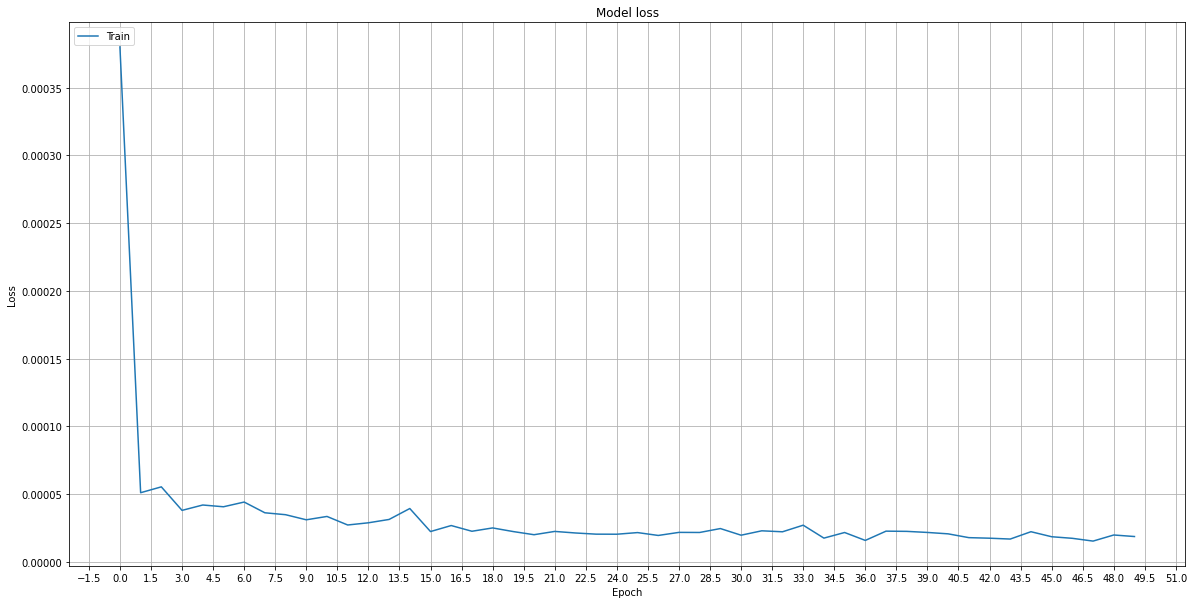

In [ ]:
# Plot training & validation loss values
fig, ax = plt.subplots(figsize=(20, 10), sharex=True)
plt.plot(history.history["loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
ax.xaxis.set_major_locator(plt.MaxNLocator(epochs))
plt.legend(["Train", "Test"], loc="upper left")
plt.grid()
plt.show()

In [ ]:
# Get the predicted values
y_pred_scaled = model.predict(apple_x_test)

# Unscale the predicted values
y_pred = scaler_pred.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler_pred.inverse_transform(apple_y_test.reshape(-1, 1))

# Mean Absolute Error (MAE)
MAE = mean_absolute_error(y_test_unscaled, y_pred)
print(f'Median Absolute Error (MAE): {np.round(MAE, 2)}')

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print(f'Mean Absolute Percentage Error (MAPE): {np.round(MAPE, 2)} %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled)) ) * 100
print(f'Median Absolute Percentage Error (MDAPE): {np.round(MDAPE, 2)} %')

Median Absolute Error (MAE): 1.85
Mean Absolute Percentage Error (MAPE): 1.72 %
Median Absolute Percentage Error (MDAPE): 1.21 %


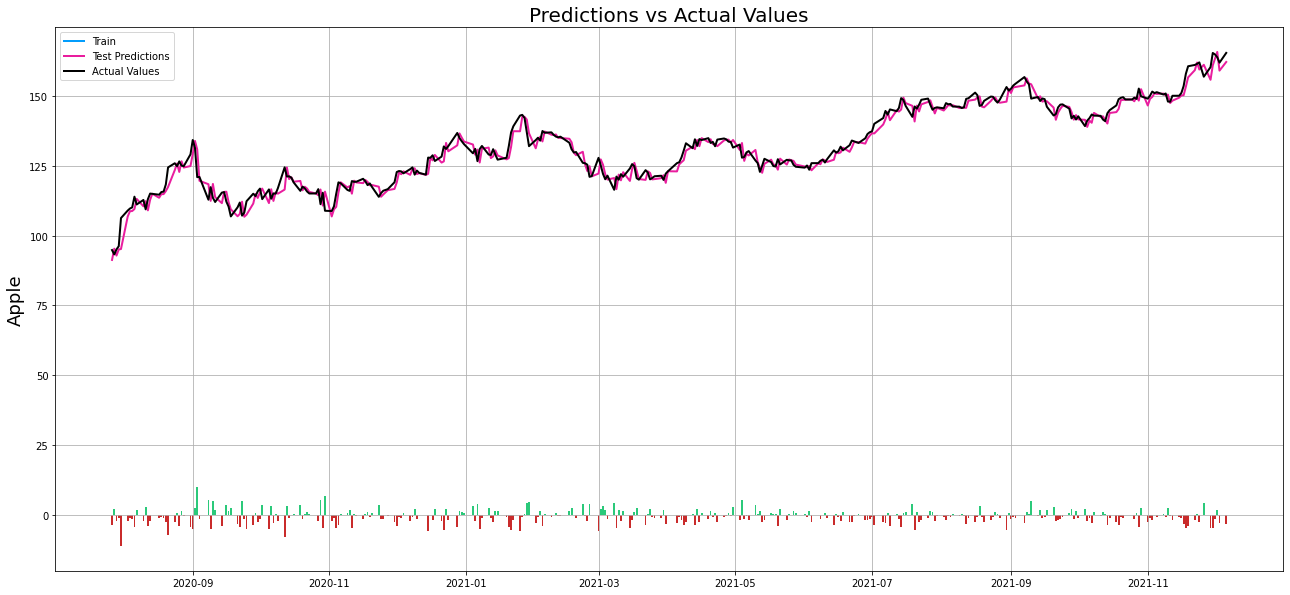

In [ ]:
# The date from which on the date is displayed
display_start_date = pd.Timestamp('today') - timedelta(days=500)

# Add the date column
apple_data_filtered_sub = apple_data_filtered.copy()
apple_data_filtered_sub['Date'] = apple_date_index

# Add the difference between the valid and predicted prices
train = apple_data_filtered_sub[:train_data_len + 1]
valid = apple_data_filtered_sub[train_data_len:]
valid.insert(1, "Prediction", y_pred.ravel(), True)
valid.insert(1, "Difference", valid["Prediction"] - valid["Close"], True)

# Zoom in to a closer timeframe
valid = valid[valid['Date'] > display_start_date]
train = train[train['Date'] > display_start_date]

# Visualize the data
fig, ax1 = plt.subplots(figsize=(22, 10), sharex=True)
xt = train['Date']; yt = train[["Close"]]
xv = valid['Date']; yv = valid[["Close", "Prediction"]]
plt.title("Predictions vs Actual Values", fontsize=20)
plt.ylabel('Apple', fontsize=18)
plt.plot(xt, yt, color="#039dfc", linewidth=2.0)
plt.plot(xv, yv["Prediction"], color="#E91D9E", linewidth=2.0)
plt.plot(xv, yv["Close"], color="black", linewidth=2.0)
plt.legend(["Train", "Test Predictions", "Actual Values"], loc="upper left")

# # Create the bar plot with the differences
x = valid['Date']
y = valid["Difference"]

# Create custom color range for positive and negative differences
valid.loc[y >= 0, 'diff_color'] = "#2BC97A"
valid.loc[y < 0, 'diff_color'] = "#C92B2B"

plt.bar(x, y, width=0.8, color=valid['diff_color'])
plt.grid()
plt.show()

In [ ]:
#Setting the timeframe for the data extraction
today = '2021-12-08'  # date.today()
last_day = '2021-12-07'
# date_today = today.strftime("%Y-%m-%d")
date_start = '2011-12-07'

stockname = 'APPLE'
symbol = 'AAPL'


import yfinance as yf
apple_df = yf.download(symbol, start = date_start, end=today)

apple_df_temp = apple_df[-sequence_length:]
apple_new_df = apple_df_temp.filter(FEATURES)

N = sequence_length

# Get the last N day closing price values and scale the data to be values between 0 and 1
last_N_days = apple_new_df[-sequence_length:].values
last_N_days_scaled = scaler.transform(last_N_days)

# Create an empty list and Append past N days
X_test_new = []
X_test_new.append(last_N_days_scaled)

# Convert the X_test data set to a numpy array and reshape the data
pred_price_scaled = model.predict(np.array(X_test_new))
pred_price_unscaled = scaler_pred.inverse_transform(pred_price_scaled.reshape(-1, 1))

# Print last price and predicted price for the next day
price_today = np.round(apple_new_df['Close'][-1], 2)
predicted_price = np.round(pred_price_unscaled.ravel()[0], 2)
change_percent = np.round(100 - (price_today * 100)/predicted_price, 2)



plus = '+'; minus = ''
print(f'The close price for Apple at {last_day} was {price_today}')
print(f'The predicted close price is {predicted_price}')

[*********************100%***********************]  1 of 1 completed
The close price for Apple at 2021-12-07 was 171.18
The predicted close price is 170.64999389648438


In [ ]:
apple_df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-01,167.479996,170.300003,164.529999,164.770004,164.770004,152052500
2021-12-02,158.740005,164.199997,157.800003,163.759995,163.759995,136739200
2021-12-03,164.020004,164.960007,159.720001,161.839996,161.839996,117938300
2021-12-06,164.289993,167.880005,164.279999,165.320007,165.320007,107497000
2021-12-07,169.080002,171.580002,168.339996,171.179993,171.179993,120405400


In [ ]:
pred_price_unscaled

array([[170.64581]], dtype=float32)

In [ ]:
scaler_pred.inverse_transform(np.array(X_test_new).reshape(-1, 1))

array([[141.42210466],
       [140.55456892],
       [142.36735321],
       [141.91000366],
       [ 20.57550171],
       [140.65279644],
       [140.26377807],
       [142.70902658],
       [142.83000183],
       [ 17.01473854],
       [141.82648887],
       [140.19593525],
       [141.95532722],
       [141.5       ],
       [ 18.4995545 ],
       [140.09060156],
       [138.780761  ],
       [139.77462558],
       [142.6499939 ],
       [ 19.09063395],
       [139.95252098],
       [138.09257127],
       [138.93048598],
       [139.13999939],
       [ 19.4721306 ],
       [137.71364413],
       [138.12164888],
       [140.0258587 ],
       [141.11000061],
       [ 17.66318131],
       [137.69391404],
       [138.03440127],
       [139.03097003],
       [142.        ],
       [ 17.90767732],
       [141.23470637],
       [140.04084482],
       [143.40243244],
       [143.28999329],
       [ 15.68147902],
       [142.19141288],
       [140.00206482],
       [143.24163956],
       [142